# 7. Diffloop majortype

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{REF_ROOT}/blacklist/hg38_bismark_loop_blacklist.bed'`  ·  _loop calls_
- `f'{loopdir}/{ct}/{ct}.{matrix}.cool'`  ·  _contacts (cool)_
- `f'{loopdir}{ct}/{ct}.{matrix}.cool'`  ·  _contacts (cool)_
- `f'{loopdir}/{ct}/{ct}.{matrix}2.cool'`  ·  _contacts (cool)_
- `f'{loopdir}/{ct}/{ct}.loop.bedpe'`  ·  _loop calls_
- `f'{outdir}majortype_{matrix}pv.cool'`  ·  _contacts (cool)_
- `f'{outdir}merged_loop.hdf'`  ·  _loop calls_
- `f'{loopdir}{ct}/{ct}.{m}.cool'`  ·  _contacts (cool)_
- `f'{outdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{outdir}loop_T.hdf'`  ·  _loop calls_
- `f'{loopdir}{ct}/{ct}.Q.cool'`  ·  _contacts (cool)_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

# ANOVA of loop matrices across cell types

In [ ]:
import os
import cooler
import pathlib
import numpy as np
import pandas as pd
from scipy.sparse import load_npz, save_npz, vstack, csr_matrix, triu
from scipy.stats import f, zscore, ranksums, pearsonr, norm
from schicluster.cool.utilities import get_chrom_offsets
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor, as_completed

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [ ]:
group_name = 'all'


In [ ]:
indir = f'{ENTEX_ROOT}/'
loopdir = f'{indir}loop/majortype/'
outdir = f'{indir}analysis/diff_loop/{group_name}/'


In [ ]:
# leg = {'exc': ['L23_IT', 'L4_IT', 'L5_IT', 'L6_IT', 'L6_IT_Car3', 'L56_NP', 'L6_CT', 'L6b', 'Amy'], 
#        'inh': ['Lamp5', 'Lamp5_LHX6', 'Sncg', 'Vip', 'Pvalb', 'Pvalb_ChC', 'Sst', 'CHD7'], 
#        'msn': ['MSN_D1', 'MSN_D2', 'Foxp2'], 
#        'sub': ['SubCtx'], 
#        'glia': ['ASC', 'ODC', 'OPC'], 
#        'mgc': ['MGC'], 
#        'smc': ['PC'], 
#        'endo': ['EC'], 
#        'fibro': ['VLMC'],
#       }
# leg['neu'] = leg['exc'] + leg['inh'] + leg['msn'] + leg['sub']
# leg['all'] = leg['neu'] + leg['glia'] + leg['mgc'] + leg['smc'] + leg['endo'] + leg['fibro']
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [ ]:
# ctgroup = []
# if '_' in group_name:
#     for xx in group_name.split('_'):
#         ctgroup.append(leg[xx])
# else:
#     for xx in leg[group_name]:
#         ctgroup.append([xx])
        
leg = L1_meta.index.copy()
ctgroup = [[xx] for xx in leg]


In [ ]:
print(len(ctgroup))

In [ ]:
# indir = '/home/jzhou_salk_edu/sky_workdir/hba/loop_majortype/'
# outdir = '/home/jzhou_salk_edu/sky_workdir/hba/loop_majortype/'
res = 10000
# group = group_name


In [ ]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]
bins_df = cooler.binnify(chrom_sizes, res)
chrom_offset = get_chrom_offsets(bins_df)


In [ ]:
bkl = pd.read_csv(f'{REF_ROOT}/blacklist/hg38_bismark_loop_blacklist.bed', sep='\t', header=None, index_col=None)


In [ ]:
result = {'Q':{}, 'E':{}, 'T':{}}
for ct in L1_meta.index:
    for matrix in 'QET':
        cool_e = cooler.Cooler(f'{loopdir}/{ct}/{ct}.{matrix}.cool')
        n = cool_e.info['group_n_cells']
        result[matrix][ct] = n

pd.DataFrame(result).sum()

In [ ]:
def compute_anova(c, matrix):
    # c, matrix = args
    ngene = int(chrom_sizes.loc[c] // res) + 1
    bkl_tmp = bkl.loc[(bkl[0]==c), [1,2]].values // res
    cov = np.zeros(ngene)
    for xx,yy in bkl_tmp:
        cov[xx-7:yy+7] = 1
    tot, last = 0, 0
    Esum, E2sum, Elast, E2last, ss_intra = [csr_matrix((ngene, ngene)) for i in range(5)]
    for ctlist in ctgroup:
        for ct in ctlist:
            cool_e = cooler.Cooler(f'{loopdir}{ct}/{ct}.{matrix}.cool')
            E = triu(cool_e.matrix(balance=False, sparse=True).fetch(c))
            cool_e2 = cooler.Cooler(f'{loopdir}/{ct}/{ct}.{matrix}2.cool')
            E2 = triu(cool_e2.matrix(balance=False, sparse=True).fetch(c))
            n = cool_e.info['group_n_cells']
            Esum += E * n
            E2sum += E2 * n
            tot += n
            # print(c, ct)
        Egroup = Esum - Elast
        E2group = E2sum - E2last
        Egroup.data = Egroup.data ** 2 / (tot - last)
        ss_intra += (E2group - Egroup)
        Elast = Esum.copy()
        E2last = E2sum.copy()
        last = tot
    Esum.data = Esum.data ** 2 / tot
    ss_total = E2sum - Esum
    ss_intra.data = 1 / ss_intra.data
    ss_total = ss_total.multiply(ss_intra)
    # print(c, ss_total.data.min(), ss_intra.data.min())

    ss_total.data = (ss_total.data - 1) * (tot - len(ctgroup)) / (len(ctgroup) - 1)
    ss_total = ss_total.tocoo()
    bklfilter = np.logical_and(cov[ss_total.row]==0, cov[ss_total.col]==0)
    distfilter = np.logical_and((ss_total.col-ss_total.row)>5, (ss_total.col-ss_total.row)<500)
    idxfilter = np.logical_and(bklfilter, distfilter)
    # print(idxfilter.sum(), len(idxfilter))
    ss_total = csr_matrix((ss_total.data[idxfilter], (ss_total.row[idxfilter], ss_total.col[idxfilter])), (ngene, ngene))
    save_npz(f'{outdir}majortype_{matrix}pv_{c}.npz', ss_total)

    return [c, matrix, tot]


In [ ]:
# for ct in L1_meta.index:
#     for matrix in 'QET':
#         cool_e = cooler.Cooler(f'{loopdir}{ct}/{ct}.{matrix}.cool')
#         n = cool_e.info['group_n_cells']
#         print(ct, matrix, n)
        

In [ ]:
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for x in chrom_sizes.index:
        for y in 'QET':
            future = executor.submit(
                compute_anova,
                c=x,
                matrix=y,
            )
            futures.append(future)

    # result = []
    for future in as_completed(futures):
        # result.append(future.result())
        # c1, c2 = result[-1][0], result[-1][1]
        tmp = future.result()
        print(f'{tmp[0]} {tmp[1]} finished')
        

In [ ]:
def chrom_iterator(input_dir, chrom_order, chrom_offset):
    for chrom in chrom_order:
        output_path = f'{input_dir}_{chrom}.npz'
        if not pathlib.Path(output_path).exists():
            continue
        chunk_size = 5000000
        data = load_npz(output_path).tocoo()
        df = pd.DataFrame({'bin1_id': data.row, 'bin2_id': data.col, 'count': data.data})
        df = df[df['bin1_id'] <= df['bin2_id']]
        for i, chunk_start in enumerate(range(0, df.shape[0], chunk_size)):
            chunk = df.iloc[chunk_start:chunk_start + chunk_size]
            chunk.iloc[:, :2] += chrom_offset[chrom]
            yield chunk


In [ ]:
for matrix in 'QET':
    output_path = f'{outdir}majortype_{matrix}pv'
    cooler.create_cooler(cool_uri=f'{output_path}.cool',
                         bins=bins_df,
                         pixels=chrom_iterator(input_dir=output_path,
                                               chrom_order=chrom_sizes.index,
                                               chrom_offset=chrom_offset
                                              ),
                         ordered=True,
                         dtypes={'count': np.float32})


In [ ]:
os.system(f'rm {outdir}majortype_*pv_c*.npz')

In [ ]:
loopall = [pd.read_csv(f'{loopdir}/{ct}/{ct}.loop.bedpe', sep='\t', index_col=None, header=None) for ct in leg]
loopall = pd.concat(loopall, axis=0)
loopall = loopall.drop([6], axis=1).drop_duplicates(subset=[0,1,4]).sort_values([0,1,4])
loopall = pd.concat([loopall[(loopall[0]==c).values] for c in chrom_sizes.index])
loopall.index = np.arange(loopall.shape[0])
loopall


In [ ]:
loopall.to_csv(f'{outdir}merged_loop.bedpe', sep='\t', index=False, header=False)
loopall.to_hdf(f'{outdir}merged_loop.hdf', key='data')


In [ ]:
for c in chrom_sizes.index:
    loopfilter = (loopall[0]==c)
    looptmp = loopall.loc[loopfilter, [1,4]].values // res
    for matrix in 'QET':
        cool = cooler.Cooler(f'{outdir}majortype_{matrix}pv.cool')
        pv = triu(cool.matrix(balance=False, sparse=True).fetch(c)).tocsr()
        loopall.loc[loopfilter, f'{matrix}anova'] = pv[(looptmp[:,0], looptmp[:,1])].A1
    print(c)


In [ ]:
loopall.to_hdf(f'{outdir}merged_loop.hdf', key='data')


## Load Loop Q

In [ ]:
loopall = pd.read_hdf(f'{outdir}merged_loop.hdf', key='data')
loopall

In [ ]:
def load_Q(ct, m):
    tmp = []
    cool_file = cooler.Cooler(f'{loopdir}{ct}/{ct}.{m}.cool').matrix(balance=False, sparse=True)
    for c in chrom_sizes.index:
        mat = cool_file.fetch(c).tocsr()
        tmp.append(mat[(loopall.loc[loopall[0]==c, 1].values // res, loopall.loc[loopall[0]==c, 4].values // res)].A1)
        # print(ct, c)
    return [ct, np.concatenate(tmp)]


In [ ]:
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for xx in leg:
        future = executor.submit(
            load_Q,
            ct=xx,
            m='Q'
        )
        futures.append(future)

    loopq = []
    for future in as_completed(futures):
        tmp = future.result()
        loopq.append(pd.DataFrame(tmp[1], columns=[tmp[0]]))
        print(f'{tmp[0]} finished')
        

In [ ]:
loopq = pd.concat(loopq, axis=1)
loopq = loopq[leg]


In [ ]:
loopq.to_hdf(f'{outdir}loop_Q.hdf', key='data')


In [ ]:
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for xx in leg:
        future = executor.submit(
            load_Q,
            ct=xx,
            m='T'
        )
        futures.append(future)

    loopt = []
    for future in as_completed(futures):
        tmp = future.result()
        loopt.append(pd.DataFrame(tmp[1], columns=[tmp[0]]))
        print(f'{tmp[0]} finished')
        

In [ ]:
loopt = pd.concat(loopt, axis=1)
loopt = loopt[leg]


In [ ]:
loopt.to_hdf(f'{outdir}loop_T.hdf', key='data')


In [ ]:
print(loopall.shape, loopq.shape, loopt.shape)

In [ ]:
loopq = pd.read_hdf(f'{outdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{outdir}loop_T.hdf', key='data')


In [ ]:
sell = (loopall['Qanova']==0) | (loopall['Eanova']==0) | (loopall['Tanova']==0)
print(sell.sum())


In [ ]:
# loopall = loopall.loc[~sell]
# loopq = loopq.loc[~sell]
# loopt = loopt.loc[~sell]


In [ ]:
thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


In [ ]:
# selb = ((zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2))
# print(selb.sum())
selb = ((zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2))
print(selb.sum())


In [ ]:
tmpq = loopq.loc[selb].values
tmpq = zscore(tmpq, axis=1)


In [ ]:
tmpt = loopt.loc[selb].values
tmpt = zscore(tmpt, axis=1)


In [ ]:
np.random.seed(0)
sel = np.random.choice(np.arange(len(tmpq)), 2000, False)


In [ ]:
cg = sns.clustermap(tmpq[sel], cmap='bwr', vmin=-3, vmax=3, method='ward', # metric='cosine', 
                    xticklabels=leg.map(L1_meta['L1_abbr']), yticklabels=[], figsize=(6,6))


In [ ]:
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()

In [ ]:
distfilter = ((loopall[4]-loopall[1])>100000) & ((loopall[4]-loopall[1])<4950000) &  (loopall[1] >= (10*res)) & (loopall[4] < (loopall[0].map(chrom_sizes) - 10*res))
loopfilter = distfilter & selb
print(selb.sum(), loopfilter.sum())


In [ ]:
loopall = loopall.loc[loopfilter]
loopq = loopq.loc[loopfilter]
loopt = loopt.loc[loopfilter]


In [ ]:
loop_list = []
for ctlist in ctgroup:
    fc1 = loopq[ctlist].mean(axis=1) / loopq.loc[:, ~loopq.columns.isin(ctlist)].mean(axis=1)
    fc2 = loopt[ctlist].mean(axis=1) / loopt.loc[:, ~loopt.columns.isin(ctlist)].mean(axis=1)
    loop_list.append(loopall.loc[(fc1>1.2) & (fc2>1.5)])


In [ ]:
[xx.shape[0] for xx in loop_list]

In [ ]:
def apa(ct):
    result = np.zeros((len(loop_list), 21, 21))
    cool = cooler.Cooler(f'{loopdir}{ct}/{ct}.Q.cool')
    for c in np.random.permutation(chrom_sizes.index):
        Q = cool.matrix(balance=False, sparse=True).fetch(c).toarray()
        decay = np.array([np.mean(np.diag(Q, k)) for k in range(dist)])
        E = np.zeros(Q.shape)
        row, col = np.diag_indices(E.shape[0])
        E[row, col] = 1
        for k in range(1, 505):
            E[row[:-k], col[k:]] = (Q[row[:-k], col[k:]]) / decay[k]
        for j,loop in enumerate(loop_list):
            looptmp = loop.loc[(loop[0]==c), [1,4]].values // res
            for xx,yy in looptmp:
                tmp = E[(xx-10):(xx+11), (yy-10):(yy+11)]
                tmp = (tmp - tmp.min()) / (tmp.max() - tmp.min())
                result[j] += tmp
                
    for j,loop in enumerate(loop_list):
        result[j] /= loop.shape[0]
        
    return result


In [ ]:
cpu = 20
dist = 505
result = np.zeros((len(leg), len(loop_list), 21, 21))
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for i,ct in enumerate(leg):
        future = executor.submit(
            apa,
            ct=ct,
        )
        futures[future] = i

    for future in as_completed(futures):
        idx = futures[future]
        result[idx] = future.result()
        print(f'{leg[idx]} finished')
        

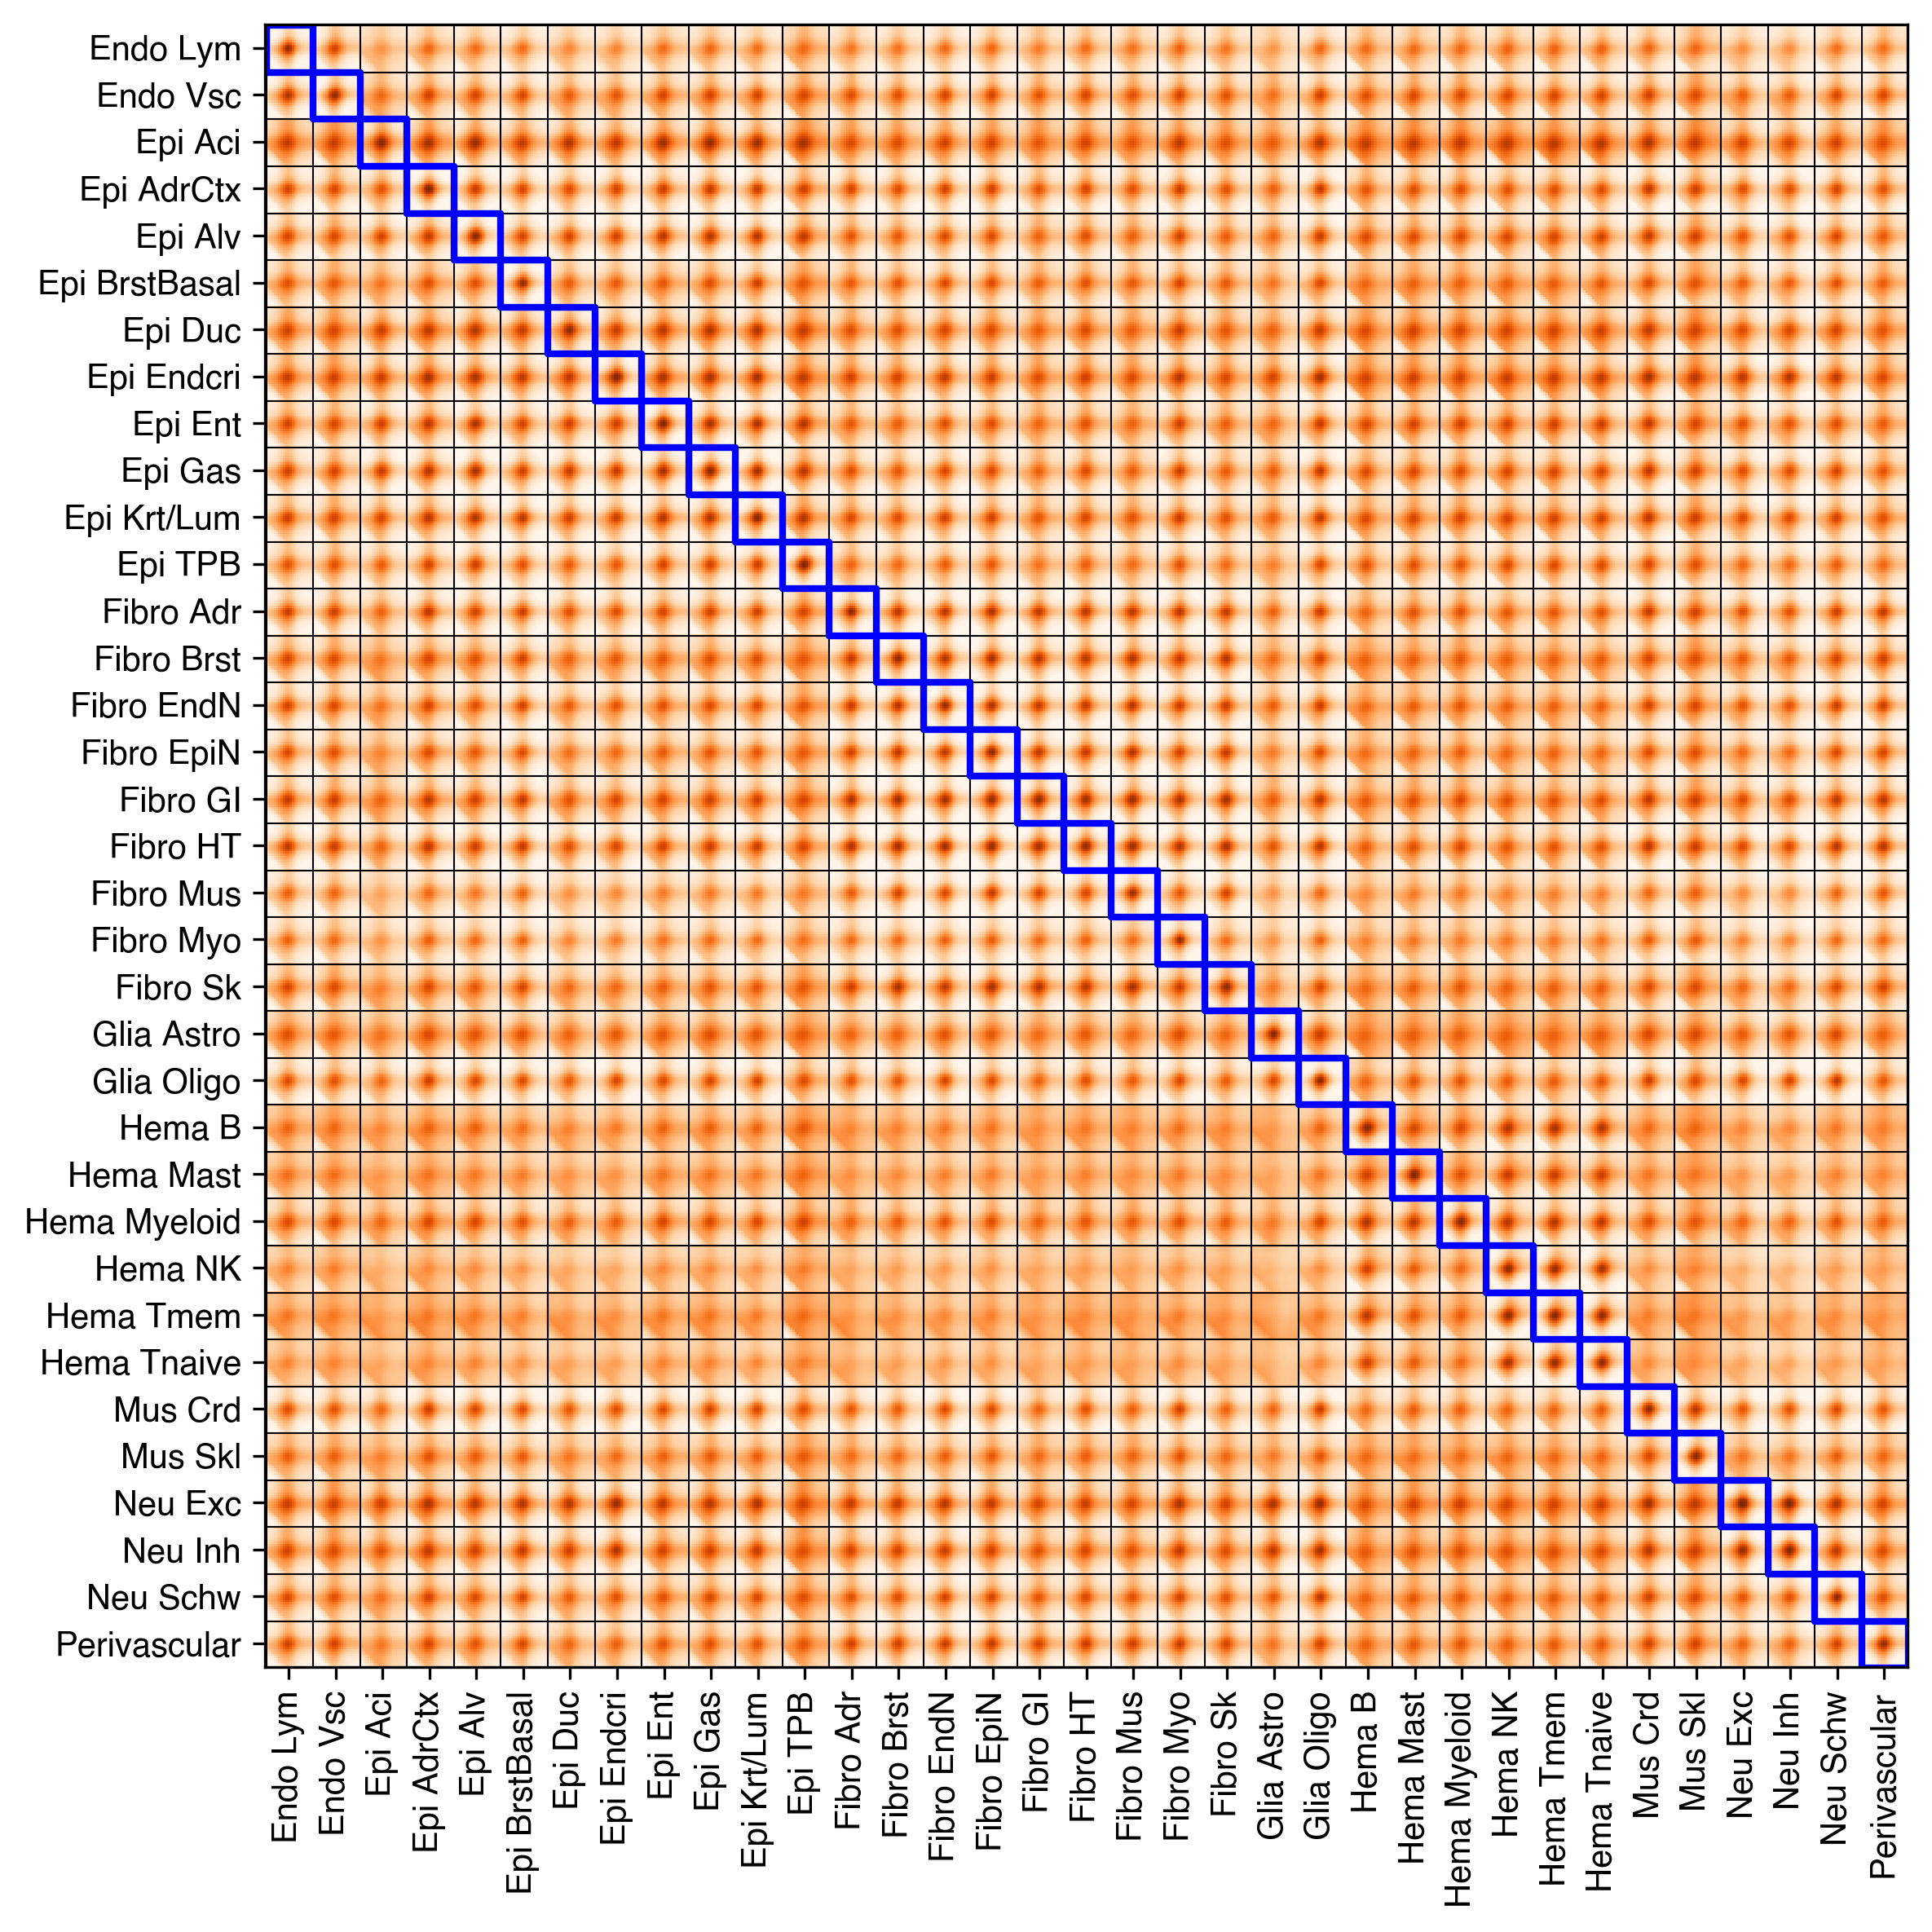

In [ ]:
# color = sns.color_palette('Reds', 1).as_hex()
color = 'b'
fig, ax = plt.subplots(figsize=(8,8), dpi=300)
ax.imshow(np.swapaxes(result, 1, 2).reshape(len(leg)*21, len(leg)*21), 
          cmap='Oranges', vmax=0.75, vmin=0.3, rasterized=True, interpolation='none')

for i in range(len(leg)):
    ax.plot([i*21, i*21], [0, len(leg)*21], 'k', linewidth=0.5)
    ax.plot([0, len(leg)*21], [i*21, i*21], 'k', linewidth=0.5)
    
for i in range(len(leg)):
    x1, x2 = i*21, (i+1)*21
    ax.plot([x1, x2, x2, x1, x1], [x1, x1, x2, x2, x1], color, linewidth=2)
    
ax.set_xlim([-0.5, len(leg)*21-0.5])
ax.set_ylim([len(leg)*21-0.5, -0.5])
ax.set_xticks(np.arange(0, len(leg)*21, 21)+10)
ax.set_xticklabels(leg.map(L1_annot), rotation=90)
ax.set_yticks(np.arange(0, len(leg)*21, 21)+10)
ax.set_yticklabels(leg.map(L1_annot))
fig.tight_layout()
fig.savefig(f'diff_loop/{group_name}_diffloop_apa.pdf', transparent=True)


In [ ]:
apa = np.zeros((len(leg), len(leg)))
for i,ct1 in enumerate(leg):
    for j,ct2 in enumerate(leg):
        tmp = result[i, j]
        apa[i,j] = np.around(tmp[10,10]/tmp[-5:, :5].mean(), decimals=2)


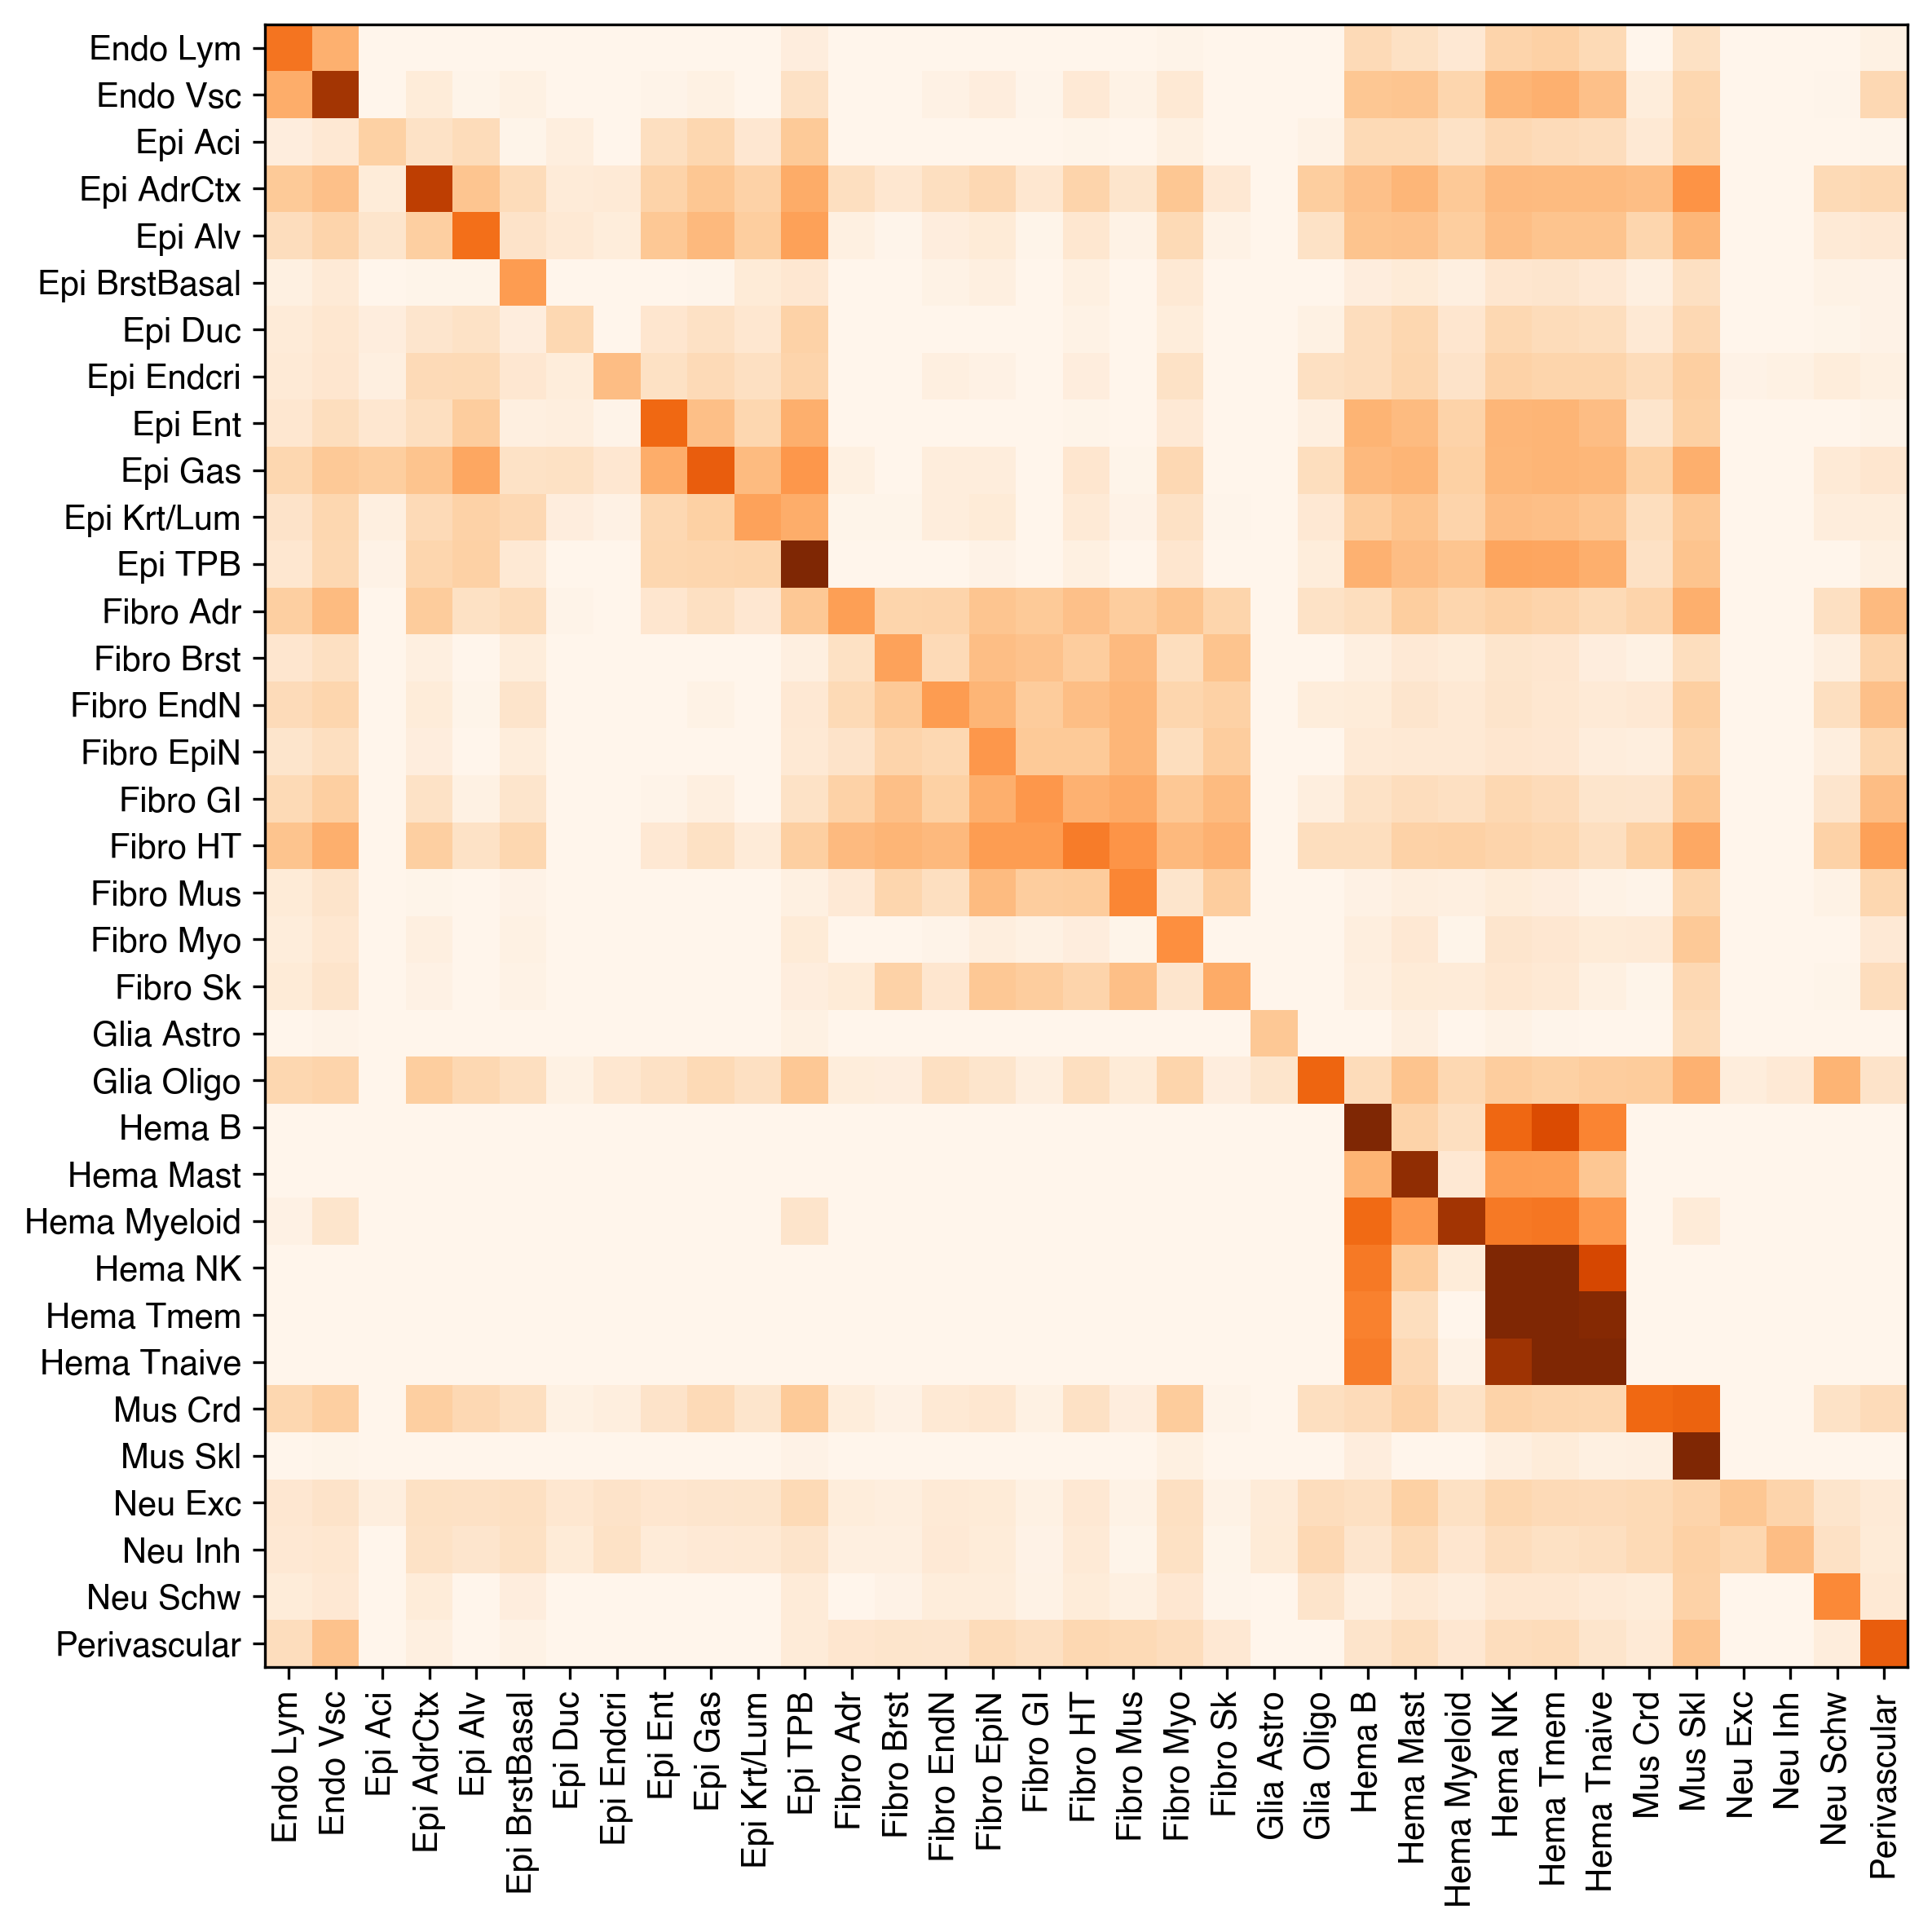

In [ ]:
fig, ax = plt.subplots(figsize=(8,8), dpi=300)
plot = ax.imshow(apa, cmap='Oranges', vmin=2, vmax=4, rasterized=True, interpolation='none')
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg.map(L1_annot), rotation=90)
ax.set_yticks(np.arange(len(leg)))
ax.set_yticklabels(leg.map(L1_annot))
# cbar = fig.colorbar(plot, ax=ax, shrink=0.2, ticks=[1,4], aspect=5)  # Adjust shrink for length, set tick positions
# cbar.set_label('APA')  # Optional label for color bar
fig.tight_layout()
fig.savefig(f'diff_loop/{group_name}_diffloop_apascore.pdf', transparent=True)


In [ ]:
np.savez(f'{outdir}apa.npz', apa=result, leg=leg)
